In [2]:
#分类读取数据
import pandas as pd
from sklearn.model_selection import train_test_split

# 读取数据
df = pd.read_csv("D:\works\PE\code\FCshaixuan_metal.csv", encoding="ISO-8859-1")

# 读取 structure 列（第 0 列）
structure = df.iloc[:, 0]

# 第一列是金属类别（Co, Fe, Cr, Ni, Ti, Zr, Hf）
category = df.iloc[:, 1]

# 第二列是标签
y = df.iloc[:, 2]

# 从第三列开始是特征
X = df.iloc[:, 3:]

# 合并，方便处理（保证对应关系）
data = pd.concat([structure, category, y, X], axis=1)

# 所有类别
categories = ["Co", "Fe", "Cr", "Ni", "Ti", "Zr", "Hf"]

train_list = []
test_list = []

# 按金属类别划分
for cat in categories:
    group = data[data.iloc[:, 1] == cat]  # 取出该类别的数据
    
    # 4:1 划分
    train_part, test_part = train_test_split(group, test_size=0.2, random_state=42)
    
    train_list.append(train_part)
    test_list.append(test_part)

# 合并所有类别的训练集和测试集
train_data = pd.concat(train_list, axis=0).sample(frac=1, random_state=42)  # 再次打乱
test_data = pd.concat(test_list, axis=0).sample(frac=1, random_state=42)

# 拆分回 structure、category、y 和 X
structure_train = train_data.iloc[:, 0]
category_train = train_data.iloc[:, 1]
y_train = train_data.iloc[:, 2]
X_train = train_data.iloc[:, 3:]

structure_test = test_data.iloc[:, 0]
category_test = test_data.iloc[:, 1]
y_test = test_data.iloc[:, 2]
X_test = test_data.iloc[:, 3:]

print("训练集大小:", X_train.shape, "测试集大小:", X_test.shape)
print("训练类别分布:\n", category_train.value_counts())
print("测试类别分布:\n", category_test.value_counts())

# 打印 X_train 和 y_train 对应关系
print("===== 训练集前n条 =====")
for i in range(2):
    print("X_train:", X_train.iloc[i].values, " | y_train:", y_train.iloc[i])

print("\n===== 测试集前n条 =====")
for i in range(1):
    print("X_test:", X_test.iloc[i].values, " | y_test:", y_test.iloc[i])

# 保存训练集和测试集到 CSV 文件
#train_data.to_csv("train_data.csv", index=False, encoding="utf-8-sig")
#test_data.to_csv("test_data.csv", index=False, encoding="utf-8-sig")

#print("训练/测试数据已保存为 train_data.csv 和 test_data.csv")


训练集大小: (402, 119) 测试集大小: (105, 119)
训练类别分布:
 center
Ti    122
Fe    102
Co     88
Zr     53
Cr     16
Hf     11
Ni     10
Name: count, dtype: int64
测试类别分布:
 center
Ti    31
Fe    26
Co    23
Zr    14
Cr     5
Hf     3
Ni     3
Name: count, dtype: int64
===== 训练集前n条 =====
X_train: [ 1.25000000e+03  2.50000000e+01  9.99999730e-01  1.00000000e+01
  2.20000000e+01  1.90212766e+01  1.01069264e+01  4.15424232e+01
  2.40214610e+01  1.03203000e+01  1.30000000e+01  7.84838321e+09
  8.00000000e+00  1.75616602e+01  3.35898565e+01  2.76393537e+01
  2.00000000e+00  0.00000000e+00  3.45453475e+01  1.14990237e+01
  2.52466777e+01  1.56732407e+01  0.00000000e+00  8.28591905e+00
  7.22319589e+00  1.85443349e+01  2.44800000e+01  7.02995586e+01
  1.24292012e+01  2.61628428e+01  2.92362535e+01  0.00000000e+00
  1.11492757e+01  3.63982024e+01  2.76391985e+02  2.74766202e+02
 -8.19255480e+00  0.00000000e+00  1.14990237e+01 -1.92050035e+00
  2.31152022e+00  4.24138852e+01  6.12494324e+00  6.63676624e+00
  2.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===========================
# Data Preprocessing
# ===========================
# Convert to numpy format
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train).ravel()
y_test_np = np.array(y_test).ravel()

# Standardization (CNN is sensitive to feature scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# CNN input requires 3D: (n_samples, n_features, n_channels)
X_train_cnn = np.expand_dims(X_train_scaled, axis=-1)
X_test_cnn = np.expand_dims(X_test_scaled, axis=-1)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)


X_train_cnn shape: (402, 119, 1)
X_test_cnn shape: (105, 119, 1)


In [4]:
# Load the model
best_model = tf.keras.models.load_model("best_cnn_regression.keras")

y_pred = best_model.predict(X_test_cnn).ravel()
y_train_cnn_pred = best_model.predict(X_train_cnn).ravel()

# Test set metrics
r2_test = r2_score(y_test_np, y_pred)
mse_test = mean_squared_error(y_test_np, y_pred)
mae_test = mean_absolute_error(y_test_np, y_pred)

# Train set metrics
r2_train = r2_score(y_train_np, y_train_cnn_pred)
mse_train = mean_squared_error(y_train_np, y_train_cnn_pred)
mae_train = mean_absolute_error(y_train_np, y_train_cnn_pred)

# Output results
print("\nModel Evaluation Results:")
print("Test Set:")
print(f"  R²:  {r2_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  MAE: {mae_test:.4f}")

print("\nTrain Set:")
print(f"  R²:  {r2_train:.4f}")
print(f"  MSE: {mse_train:.4f}")
print(f"  MAE: {mae_train:.4f}")




13/13 [==============================] - 0s 3ms/step

Model Evaluation Results:
Test Set:
  R²:  0.4000
  MSE: 0.0151
  MAE: 0.1032

Train Set:
  R²:  0.4108
  MSE: 0.0151
  MAE: 0.1015


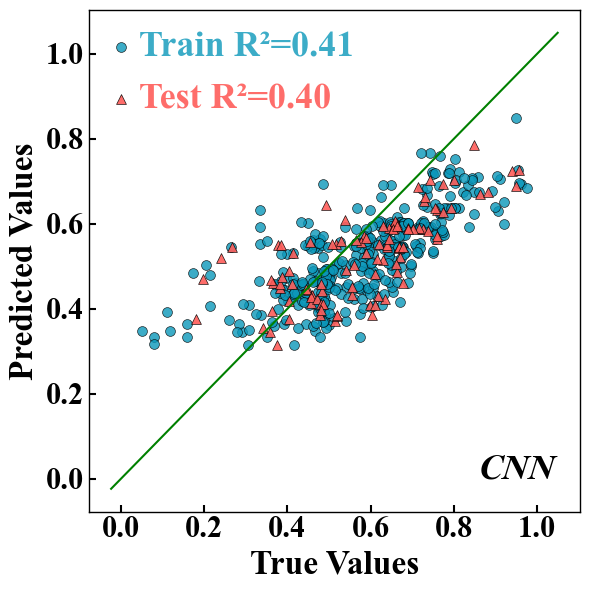

In [16]:
# ===========================
# 8. 真实值 vs 预测值 可视化
# ===========================
# 绘制散点图
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick

plt.figure(figsize=(6, 6))
plt.scatter(y_train_np, y_train_cnn_pred, alpha=0.8, color="#0b97ba",edgecolors="black", 
            linewidths=0.5,label='Train R²=0.41', s=50)
plt.scatter(y_test_np, y_pred, alpha=0.9, color="#fe5d5a",edgecolors="black", 
            linewidths=0.5, label=(
        f"Test R²={r2_test:.2f}"
    ), s=50, marker='^')
# 添加理想预测线（y=x）
min_val = min(min(y_test_np), min(y_pred), min(y_train_np), min(y_train_cnn_pred))
max_val = max(max(y_test_np), max(y_pred), max(y_train_np), max(y_train_cnn_pred))
padding = (max_val - min_val) * 0.08  # 线段延长 5%
plt.plot(
    [min_val - padding, max_val + padding],
    [min_val - padding, max_val + padding],
     color='green'
)

# 调整图例（legend）
# ================================
leg = plt.legend(
    loc='upper left',
    prop={'family': 'Times New Roman', 'weight': 'bold', 'size': 26},
     frameon=False,   # ✅ 关闭图例边框
     bbox_to_anchor=(0, 0.95),
     handletextpad=-0.5 ,
     borderaxespad=-0.5   
)
# 获取 legend 中的 handles（图例符号）和 texts（文字）
handles = leg.legend_handles
texts = leg.get_texts()

# 让文字颜色与对应散点颜色一致
for handle, text in zip(handles, texts):
    try:
        text.set_color(handle.get_facecolor()[0])  # scatter 点
    except:
        text.set_color(handle.get_color())          # 理想预测线

# ============================
# 坐标轴标题设置
# ============================
plt.xlabel('True Values', fontsize=24, fontweight='bold', fontfamily='Times New Roman')
plt.ylabel('Predicted Values', fontsize=24, fontweight='bold', fontfamily='Times New Roman')

# 获取当前坐标轴
ax = plt.gca()

# 添加文字标记
ax.text(
    0.95, 0.05,          # 坐标位置：x=0.95 (接近右边缘), y=0.05 (接近底部)
    'CNN',               # 内容
    transform=ax.transAxes,  # 关键：使用轴坐标系 (0到1)
    fontsize=26,         # 字体大小
    fontweight='bold',   # 加粗
    fontfamily='Times New Roman',
    fontstyle='italic',  # ✅ 设置为斜体
    ha='right',          # 水平对齐：右对齐
    va='bottom',         # 垂直对齐：底部对齐
    # bbox=dict(facecolor='white', alpha=0.5, edgecolor='none') # 可选：如果背景太花可以加个半透明底色
)
# ======
# ===============================
# 3) 主刻度：朝内、加粗、长度 + 字体加粗
# ===============================
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=5,
    width=1.5,
    labelsize=2
)
# —— 设置刻度标签字体加粗（X 和 Y）——
plt.xticks(fontsize=22, fontweight='bold', fontfamily='Times New Roman')
plt.yticks(fontsize=22, fontweight='bold', fontfamily='Times New Roman')
# 设置边框线宽
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1)
# 设置坐标轴范围相等，确保对角线是45度

plt.tight_layout()
plt.savefig(r"D:\works\PE\稿件\Figure\All_models_metal\CNN.png", dpi=300, bbox_inches='tight')
# 显示图表
plt.show()
